Membuat simulasi dokumen yang terkena gangguan sinyal...


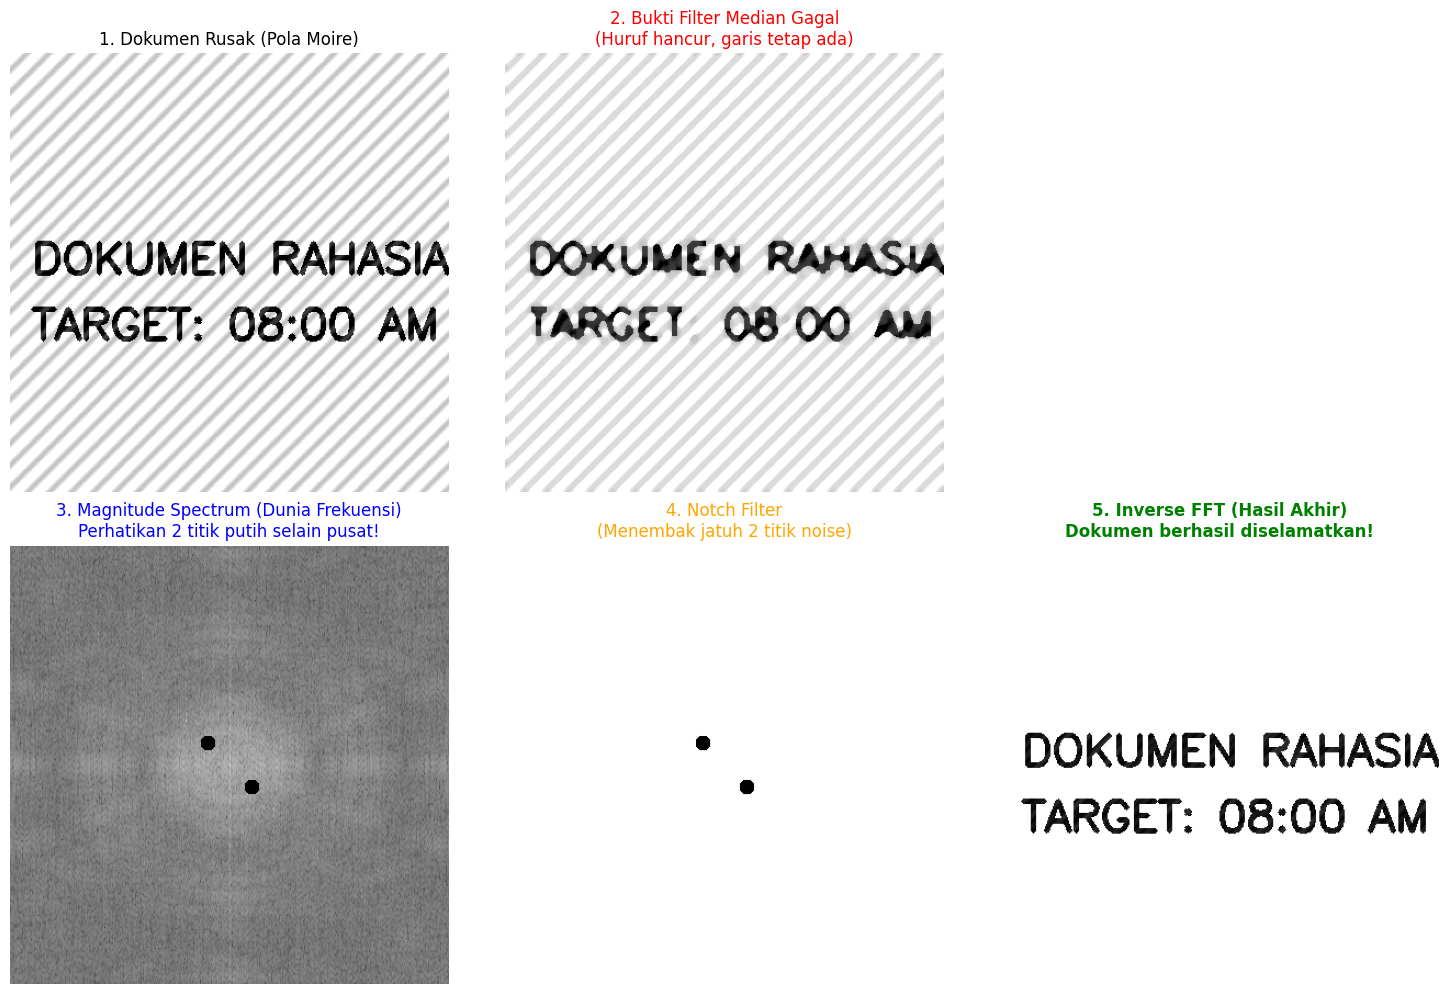

In [124]:
# ======================================================================
# PRAKTIKUM 5: FOURIER TRANSFORM (FREQUENCY DOMAIN)
# Misi: Menyelamatkan Dokumen Rahasia dari Pola Moire (Noise Periodik)
# ======================================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("Membuat simulasi dokumen yang terkena gangguan sinyal...")

# 1. PERSIAPAN DATA: Membuat Dokumen Bersih
dokumen = np.ones((400, 400), dtype=np.uint8) * 255
cv2.putText(dokumen, "DOKUMEN RAHASIA", (20, 200), cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)
cv2.putText(dokumen, "TARGET: 08:00 AM", (20, 260), cv2.FONT_HERSHEY_SIMPLEX, 1.3, 0, 4)

# 2. MENSIMULASIKAN POLA MOIRE (Noise Periodik berupa gelombang Sinus)
y, x = np.mgrid[0:400, 0:400]
# Membuat gelombang diagonal yang berulang
noise_moire = 60 * np.sin(2 * np.pi * (0.05 * x + 0.05 * y))
dokumen_kotor = np.clip(dokumen + noise_moire, 0, 255).astype(np.uint8)

# -- PEMBUKTIAN: MENGAPA FILTER PERTEMUAN 4 GAGAL? --
# Membuktikan Median Filter tidak bisa menghapus Moire
gagal_median = cv2.medianBlur(dokumen_kotor, 9)

# ======================================================================
# 3. MASUK KE DUNIA FREKUENSI (FAST FOURIER TRANSFORM)
# ======================================================================
# Menghitung FFT 2D
dft = cv2.dft(np.float32(dokumen_kotor), flags=cv2.DFT_COMPLEX_OUTPUT)
# Menggeser frekuensi rendah (DC) ke tengah matriks
dft_shift = np.fft.fftshift(dft)

# Menghitung Magnitude Spectrum (Untuk divisualisasikan ke manusia)
# Frekuensi rendah di tengah, frekuensi tinggi di pinggir.
magnitude_spectrum = 20 * np.log(cv2.magnitude(dft_shift[:, :, 0], dft_shift[:, :, 1]) + 1)

# ======================================================================
# 4. FILTERING: OPERASI NOTCH FILTER (Menembak jatuh bintang noise)
# ======================================================================
baris, kolom = dokumen_kotor.shape
tengah_b, tengah_k = baris // 2, kolom // 2

# Membuat Masking (Semuanya 1 / Lulus)
mask = np.ones((baris, kolom, 2), np.uint8)

# Menganalisis Spectrum dan melihat ada 2 "Bintang Terang" di luar pusat.
# Itu adalah frekuensi dari Pola Moire! Kita harus memblokirnya (Beri nilai 0).
# Koordinat ini disesuaikan dengan posisi "bintang" pada spektrum.
r = 7 # Jari-jari tembakan
offset = 20

# Membuat grid koordinat untuk menghitung lingkaran
y_grid, x_grid = np.ogrid[-tengah_b:baris-tengah_b, -tengah_k:kolom-tengah_k]

# 1. Tembak Bintang Kiri Atas (tengah - offset)
mask1 = (x_grid + offset)**2 + (y_grid + offset)**2 < r**2
mask[mask1] = 0

# 2. Tembak Bintang Kanan Bawah (tengah + offset)
mask2 = (x_grid - offset)**2 + (y_grid - offset)**2 < r**2
mask[mask2] = 0

# Kalikan Spectrum dengan Masking
dft_terfilter = dft_shift * mask

# ======================================================================
# 5. KEMBALI KE DUNIA NYATA (INVERSE FFT)
# ======================================================================
# Geser kembali ke pojok
f_ishift = np.fft.ifftshift(dft_terfilter)
# Inverse Transform
img_kembali = cv2.idft(f_ishift)
# Ambil magnitudo fisiknya
img_bersih = cv2.magnitude(img_kembali[:, :, 0], img_kembali[:, :, 1])

# Normalisasi kembali ke rentang 0-255
img_bersih = cv2.normalize(img_bersih, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# Hitung Magnitude Spectrum yang sudah difilter (untuk melihat titik hitamnya)
magnitude_terfilter = 20 * np.log(cv2.magnitude(dft_terfilter[:, :, 0], dft_terfilter[:, :, 1]) + 1)

# Langkah Post-Processing
img_final_putih = cv2.normalize(img_bersih, None, 0, 255, cv2.NORM_MINMAX)
img_final_putih[img_final_putih > 150] = 255 # Thresholding

# ======================================================================
# 6. VISUALISASI HASIL SANG PENYELAMAT
# ======================================================================
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("1. Dokumen Rusak (Pola Moire)")
plt.imshow(dokumen_kotor, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("2. Bukti Filter Median Gagal\n(Huruf hancur, garis tetap ada)", color='red')
plt.imshow(gagal_median, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("3. Magnitude Spectrum (Dunia Frekuensi)\nPerhatikan 2 titik putih selain pusat!", color='blue')
plt.imshow(magnitude_terfilter, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("4. Notch Filter\n(Menembak jatuh 2 titik noise)", color='orange')
plt.imshow(mask[:, :, 0], cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("5. Inverse FFT (Hasil Akhir)\nDokumen berhasil diselamatkan!", color='green', fontweight='bold')
plt.imshow(img_final_putih, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

### Tugas Mandiri:
1. Skrip diatas memiliki koordinat 'tembakan' yang sengaja disalahkan sedikit. Coba kalian ubah koordinat X dan Y pada variabel mask sampai garis Moire benar-benar bersih 100%!
2. Apa yang terjadi kalau titik putih raksasa di tengah yang kita hitamkan?

Jika titik putih yang ditengah dihitamkan maka yang terjadi adalah perubahan background warna citra asli akan menjadi warna hitam.

Titik tengah spektrum mewakili komponen frekuensi nol (DC), yaitu nilai rata-rata intensitas cahaya global citra. Komponen ini menyimpan informasi fundamental mengenai pencahayaan dan struktur dasar objek.

Jika titik ini dihilangkan (masking), citra hasil Inverse Fourier Transform akan mengalami:

<ul>
  <li> Kehilangan Kecerahan Global: Citra menjadi sangat gelap atau hitam karena informasi intensitas rata-rata telah terhapus.
  <li>Efek High-Pass Filter: Hanya menyisakan frekuensi tinggi seperti tepi objek (edges) dan tekstur, sementara bentuk utama dan latar belakang putih akan hilang.
</ul>
Kesimpulan: Frekuensi rendah (pusat) adalah pilar struktur citra, sedangkan frekuensi tinggi (pinggir) adalah detail. Dalam Notch Filtering, titik pusat wajib dipertahankan agar informasi visual utama tetap utuh.

### Tulis dalam laporan:
1. Tuliskan fungsi matematis mengapa kita harus melakukan np.fft.fftshift setelah melakukan DFT!

Secara default, algoritma Discrete Fourier Transform (DFT) menempatkan komponen frekuensi nol (DC) pada sudut kiri atas matriks. Pergeseran dilakukan menggunakan fungsi np.fft.fftshift dengan dasar matematis:$$f(x,y) \cdot (-1)^{x+y} \longleftrightarrow F(u - \frac{M}{2}, v - \frac{N}{2})$$Tujuan pergeseran:<br>
<ul>
  <li>Visualisasi: Memindahkan komponen frekuensi rendah ke pusat spektrum agar lebih mudah dianalisis secara intuitif (pusat sebagai titik referensi).
  <li>Simetri Filter: Memungkinkan pembuatan filter (seperti Notch Filter atau Low-pass) yang berpusat di tengah gambar menggunakan koordinat polar atau lingkaran.
</ul>

2. Analisis koordinat: Mengapa titik-titik noise pada pola Moire selalu muncul secara berpasangan dan simetris terhadap titik pusat di Magnitude Spectrum? (Clue: Sifat konjugat kompleks Fourier).

Titik noise pada pola Moire muncul secara berpasangan dan simetris terhadap pusat karena Sifat Simetri Konjugat Fourier. Untuk citra riil $f(x,y)$, spektrum Fouriernya $F(u,v)$ memenuhi persamaan:$$F(u, v) = F^*(-u, -v)$$Analisis:<br>
<ul>
  <li>Karena magnitudo $|F(u,v)|$ sama dengan $|F(-u,-v)|$, setiap frekuensi sinusoidal (noise Moire) akan muncul sebagai dua titik terang yang merupakan refleksi satu sama lain terhadap titik pusat.
  <li>Itulah sebabnya penghapusan noise periodik harus dilakukan pada kedua titik simetris tersebut agar seluruh komponen energi gelombang noise hilang dari citra.
</ul>
3. Lampirkan screenshot hasil pencarian koordinat Notch Filter kalian yang paling optimal.

Berdasarkan frekuensi noise sinusoidal sebesar 0.05 pada citra berukuran 400x400, titik noise terletak tepat pada jarak 20 piksel dari pusat. <br> Parameter Optimal:
<ul>
  <li>Offset: 20 (Hasil dari $0.05 \times 400$)
  <li>Radius (r): 7 (Cukup lebar untuk menyapu bersih energi noise tanpa merusak detail teks).
  <li>Metode: Lingkaran (np.ogrid atau cv2.circle).
</ul>